In [ ]:
import pandas as pd
from facter.utils import setup_logging, generate_recommendations, evaluate_at_k_from_lists, evaluate_valid_at_k
from facter.data import DatasetLoader
import matplotlib.pyplot as plt

### Dataset: MovieLens

In [4]:
logger = setup_logging()
loader = DatasetLoader('ml-1m')
ml = loader.prepare_prompts().dropna().reset_index(drop=True)

Building sequences (ml-1m): 100%|██████████| 6040/6040 [00:03<00:00, 1512.28it/s]


In [5]:
ml.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: F\n- age...,"Watch history:\n1. Girl, Interrupted (1999)\n2...",F,Under 18,K-12 student,720,Wallace & Gromit: The Best of Aardman Animatio...
1,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Back to the Future (1985)\n...,F,Under 18,K-12 student,260,Star Wars: Episode IV - A New Hope (1977)
2,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Titanic (1997)\n2. Cinderel...,F,Under 18,K-12 student,919,"Wizard of Oz, The (1939)"
3,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Cinderella (1950)\n2. Meet ...,F,Under 18,K-12 student,608,Fargo (1996)
4,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Meet Joe Black (1998)\n2. L...,F,Under 18,K-12 student,2692,Run Lola Run (Lola rennt) (1998)


In [ ]:
# total number of samples in the MovieLens dataset
len(ml)

939809

In [10]:
# number of female users in MovieLens
print('number of female users:', len(ml[ml['gender']=='F']))
print('number of male users:', len(ml[ml['gender']=='M']))


number of female users: 229350
number of male users: 710459


In [13]:
# number of distinct of occupations
print(len(list(ml['occupation'].drop_duplicates())))

21


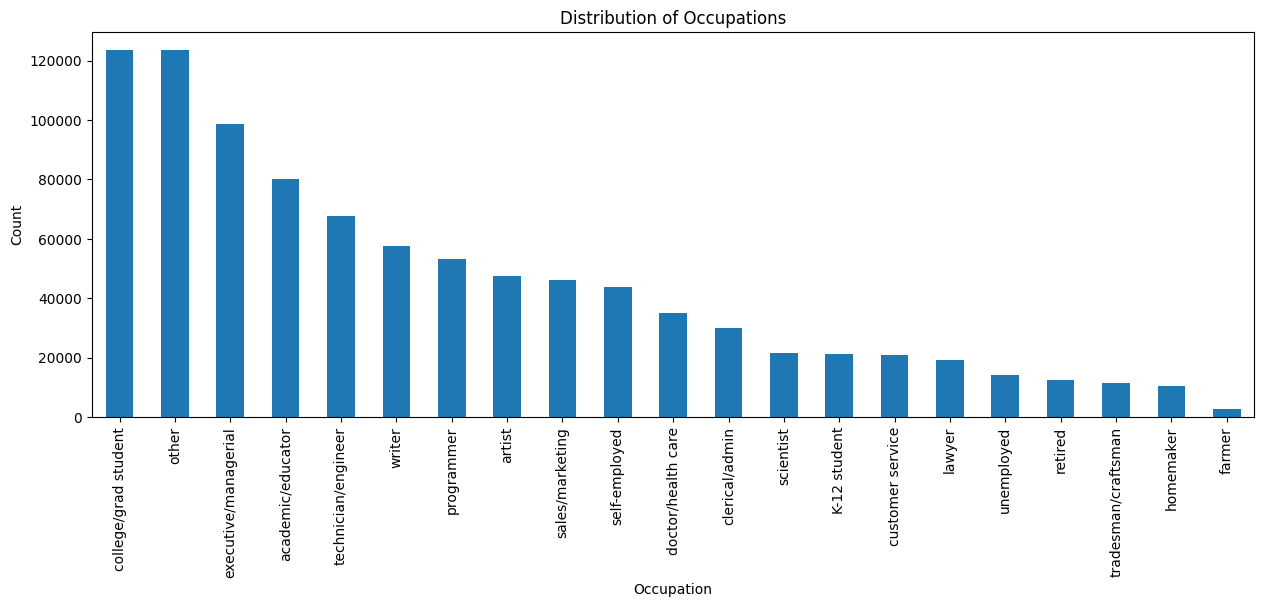

In [23]:
# Bar plot of occupations
counts = ml["occupation"].value_counts()
plt.figure(figsize=(15,5))
counts.plot(kind='bar')
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Occupations")
plt.show()

In [25]:
# number of distinct target titles
print(len(list(ml['target_title'].drop_duplicates())))

3668


In [30]:
# first 2500 samples from MovieLens
first = ml[:2500]

# number of distinct target titles
print(len(list(first['target_title'].drop_duplicates())))

1160


### Datset: Amazon

In [31]:
logger = setup_logging()
loader = DatasetLoader('amazon')
am = loader.prepare_prompts().dropna().reset_index(drop=True)
am.head()

2026-01-20 11:03:05,979 - INFO - Amazon reviews already downloaded.
2026-01-20 11:03:05,979 - INFO - Amazon metadata already downloaded.
Loading Amazon data: 3410019it [00:21, 155846.07it/s]
Loading Amazon metadata: 203766it [00:01, 117779.66it/s]
Building sequences (amazon): 100%|██████████| 295218/295218 [00:36<00:00, 8121.11it/s]


,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Grimm\n2. Intolerable Cruel...,M,55-64,farmer,B005LAJ1LS,Bored to Death: Season 3
1,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Intolerable Cruelty\n2. Fra...,M,55-64,farmer,6303574289,"Star Trek - The Next Generation, Episode 74: T..."
2,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier: Season 10\n2. Fras...,M,55-64,farmer,B000063V8R,Star Trek The Next Generation - The Complete T...
3,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier - The Complete Fina...,M,55-64,farmer,B00NC61CSS,A Merry Friggin' Christmas [Blu-ray]
4,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Frasier: Season 1\n2. Frasi...,M,55-64,farmer,B000063V8T,Star Trek The Next Generation - The Complete F...


In [32]:
# total number of samples in the Amazon dataset
len(am)

808669

In [33]:
# number of female users in MovieLens
print('number of female users:', len(am[am['gender']=='F']))
print('number of male users:', len(am[am['gender']=='M']))

number of female users: 398077
number of male users: 410592


In [34]:
# number of distinct of occupations
print(len(list(am['occupation'].drop_duplicates())))

20


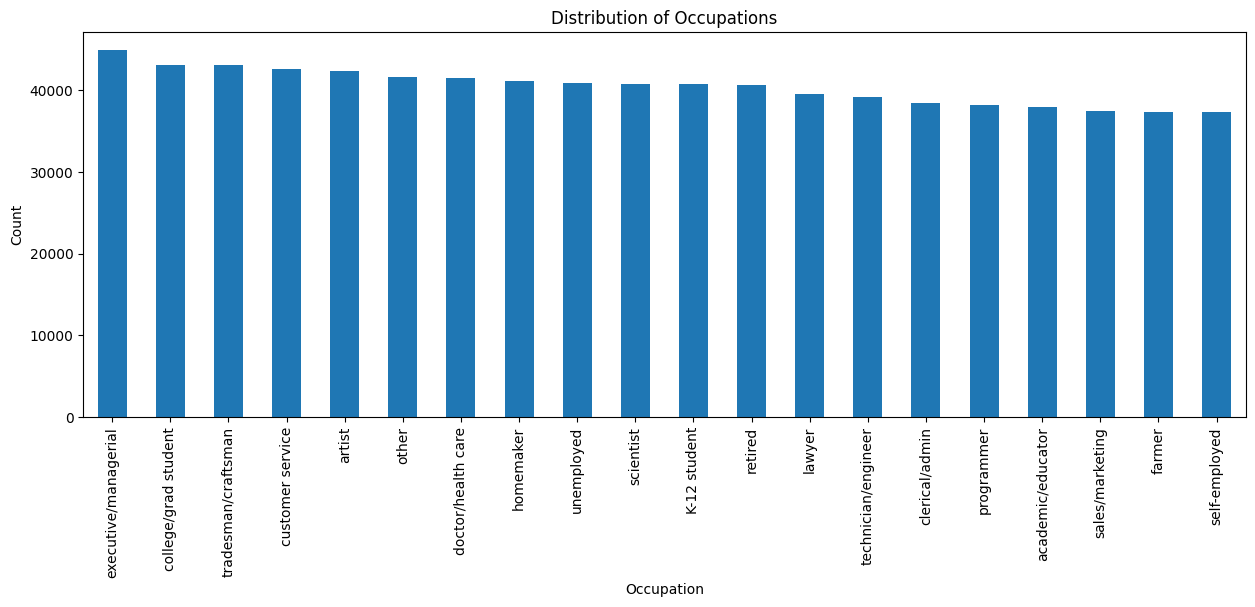

In [35]:
# Bar plot of occupations
counts = am["occupation"].value_counts()
plt.figure(figsize=(15,5))
counts.plot(kind='bar')
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Occupations")
plt.show()


In [36]:
# number of distinct target titles
print(len(list(am['target_title'].drop_duplicates())))

54470


In [37]:
# first 3750 samples from Amazon
first_am = am[:3750]
# number of distinct target titles
print(len(list(first_am['target_title'].drop_duplicates())))

2943
